# Code from Gan

In [2]:
# This program is to reconstruct the signal of the signal of Kelvin waves
# Basic Settring 
# # import package
import sys
import h5py
import numpy as np

# from cartopy import crs as ccrs
# from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

# Define the path to the Theory.py file directly
theory_file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py"

# Load the module from the file path
spec = importlib.util.spec_from_file_location("Theory", theory_file_path)
th = importlib.util.module_from_spec(spec)
sys.modules["Theory"] = th
spec.loader.exec_module(th)

level_index = 5

# level_index = 18

# sys.path.append("/home/b11209013/Package/")
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/")
import Theory as th

# Verify that it's the correct module
print(th)
# ================== #
# functions
# # plot setting
def plot_setting():
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["font.family"] = "serif"

# ================== #
# main function
def main(PR):
    # load data
    path:str = f"/home/b11209013/2024_Research/PowerSpec_Dycore/data/pr{PR}/"

    # # range latitude
    lat = np.linspace(-90, 90, 64)
    
    lat_cond = np.where((lat>=-15)&(lat<=15))[0]
    # lat_cond = np.where((lat>=-45)&(lat<=45))[0]
    
    lat = lat[lat_cond]
    print(lat)
    # prec data
    # with h5py.File(path+"prec_pr50.dat") as f:
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, lat_cond]
    prec -= prec.mean(axis=0)
    prec *= 86400
    
    
    # u-wind
    # with h5py.File(path+"u_pr50.dat") as f:
        # u = f["u"][:, 5, lat_cond]

    # u -= u.mean(axis=0)

    # pressure
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, lat_cond]
    p -= p.mean(axis=0)

    # z
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
        z = f["z"][:, level_index, lat_cond]
    z -= z.mean(axis=0)





    # ================= #
    # Reconstruct Kelvin waves
    # # FFT
    # precpitation
    prec_fft = np.array([
        np.fft.fftshift(np.fft.fft2(prec[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])
    # (lat, time, lon)

    p_fft = np.array([
        np.fft.fftshift(np.fft.fft2(p[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    z_fft = np.array([
        np.fft.fftshift(np.fft.fft2(z[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])



    # # # u-wind
    # u_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(u[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])

    # # # # v-wind
    # v_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(v[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])


    # # dimension for bandpass filter
    wn = np.linspace(-64, 64, 128)
    fr = np.linspace(-2, 2, 78000)

    wnm, frm = np.meshgrid(wn, fr)
    kel_curves = lambda k, ed: (86400/(2*np.pi*6.371e6))*np.sqrt(9.81*ed)*k

    ed8 = kel_curves(wnm, 8)
    ed25 = kel_curves(wnm, 25)
    ed90 = kel_curves(wnm, 90)

    # cond = np.logical_or.reduce([
    #     wnm <= 1, wnm >= 6,
    #     # frm > -0.05, frm < -0.5,     
    #     frm > -0.01, frm < -0.15,     
        
    #     # frm >= -ed8.Kelvin(), frm <= -ed90.Kelvin()
    #     frm >= -ed8.Kelvin(), frm <= -ed25.Kelvin()
        
    #     ])
    cond = (
    # (wnm >= 0) & (wnm <= 3) &
    (wnm >= 0) & (wnm <= 3) &
    (frm >= 0.) & (frm <= 0.12) &        
    # (frm <= ed90) & (frm >= ed8)
    (frm <= ed25) & (frm >= ed8)
        
        
        
)
    
    # # bandpass filter and inverse FFT
    # # # IFFT
    prec_ifft = []
    # u_ifft = []
    # v_ifft = []
    p_ifft = []
    z_ifft = []
    
    

    # for i in range(len(lat_cond)):
    #     prec_filted = np.where(cond == True, 0, prec_fft[i]*2)
    #     prec_ifft.append(np.fft.ifft2(np.fft.ifftshift(prec_filted)))


    #     # u_filted = np.where(cond == True, 0, u_fft[i]*2)
    #     # u_ifft.append(np.fft.ifft2(np.fft.ifftshift(u_filted)))

    #     # v_filted = np.where(cond == True, 0, v_fft[i]*2)
    #     # v_ifft.append(np.fft.ifft2(np.fft.ifftshift(v_filted)))

    #     p_filted = np.where(cond == True, 0, p_fft[i]*2)
    #     p_ifft.append(np.fft.ifft2(np.fft.ifftshift(p_filted)))

    #     z_filted = np.where(cond == True, 0, z_fft[i]*2)
    #     z_ifft.append(np.fft.ifft2(np.fft.ifftshift(z_filted)))


        # Applying the bandpass filter and inverse FFT
    def apply_ifft_with_filter(data_fft, cond):
        return np.stack([
            np.fft.ifft2(np.fft.ifftshift(np.where(cond, data_fft[i] * 2, 0)[:,::-1])).real
            for i in range(data_fft.shape[0])
        ], axis=1)

    # Reconstructing signals
    prec_recon = apply_ifft_with_filter(prec_fft, cond)
    p_recon = apply_ifft_with_filter(p_fft, cond)
    z_recon = apply_ifft_with_filter(z_fft, cond)
    

    

    return prec_recon, p_recon, z_recon
# ===================== #
# execution section
if __name__ == "__main__":
    PR = 0
    # prec_recon, p_recon = main(PR)
    prec_recon, p_recon, z_recon = main(PR)
    
    print("done")

#########################################################

<module 'Theory' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py'>
[-12.85714286 -10.          -7.14285714  -4.28571429  -1.42857143
   1.42857143   4.28571429   7.14285714  10.          12.85714286]
done


In [3]:
# load data
print(PR)
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
    z = f["z"][:, level_index, :]
z -= z.mean(axis=0)

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]
prec -= prec.mean(axis=0)
prec *= 86400

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, :]
p -= p.mean(axis=0)

0


# Read barotropic (all level) data

In [4]:
def read_var_at_level(PR, var, start_day, end_day, level_index):
    import h5py
    if PR  in [0, 10, 30]:
        common_path = "/data92/PeterChang/back_to_master1220"
    else:
        common_path = "/data92/PeterChang2/"
        
    y_dim = 64
    x_dim = 128
    var_all = np.zeros(((int((end_day - start_day)*4), y_dim, x_dim)))

    aa = 0
    for day in range(start_day, end_day, 25):
        path = common_path + f"/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/HSt42_{PR}/RH80_PR{PR}_20000day_startfrom_{day}day_final.dat"
        with h5py.File(path) as f:
            var_all[aa:aa+100] = f[var][:, level_index,:]#.mean(axis=1)
        aa += 100
    return var_all
    



In [5]:
v = read_var_at_level(PR, "grid_v_c_xyzt", 500, 20000, level_index) 
v -= v.mean(axis=0)

u = read_var_at_level(PR, "grid_u_c_xyzt", 500, 20000, level_index) 
u -= u.mean(axis=0)

In [6]:
EMF = u * v

# extract wave number code from Boss

In [7]:
def fft_filtering(data,dim,wave_numbers):
    n_points = data.shape[dim]
    n_dim    = data.ndim
    print(n_points)
    print(n_dim)
    # move the dimension of interest to the first place 
    order             = ['i','j','k','l','m','n']
    old_dim  = ""
    for i in range(dim+1):
        old_dim         += str(order[i])
    print(old_dim)

    order.insert(0, order.pop(dim))
    new_dim  = ""
    for i in range(dim+1):
        new_dim         += str(order[i])
    print(new_dim)
    # Perform FFT
    fft_values     = np.fft.fft(data,axis=dim)
    frequencies    = np.fft.fftfreq(n_points)

    # swapped data order 
    fft_values     = np.einsum(old_dim+'->'+new_dim, fft_values)

    # find which wave number should be kept
    posi           = np.where(np.isin(np.abs(frequencies*n_points),wave_numbers))[0]

    # filtering data
    filtered_data  = np.zeros_like(fft_values)
    filtered_data[posi,:] = fft_values[posi,:]
    
    # swapped back to original order 
    filtered_data  = np.einsum(new_dim+'->'+old_dim, filtered_data)
    filtered_data  = np.fft.ifft(filtered_data,axis=dim).real
    
  
    return filtered_data




In [8]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

if 'EMF_wn1_2' in globals():
    del EMF_wn1_2



prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])

z_wn1_2      = fft_filtering(z,dim=2,wave_numbers=[1,2,3,4,5,6]) # wave number 1~2 for shading
EMF_wn1_2     = fft_filtering(u*v,dim=2,wave_numbers=[1,2,3,4,5,6]) # wave number 1~2 for shading




128
3
ijk
kij
128
3
ijk
kij
128
3
ijk
kij


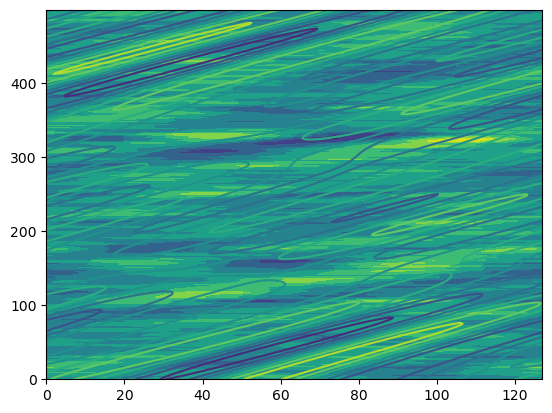

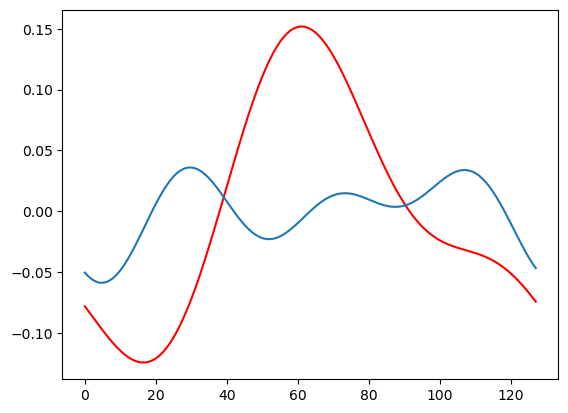

In [9]:
# For check the difference between Boss and Gan's code
plt.figure()
plt.contourf(prec_wn1[1000:1500,lat_cond,:].mean(axis=1))
plt.contour(prec_recon[1000:1500,:,:].mean(axis=1))

plt.figure()
plt.plot(prec_wn1[100,lat_cond,:].mean(axis=0),'r')
plt.plot(prec_recon[100,:,:].mean(axis=0))

# For Z lead prec

In [10]:
# Select time index
def Cal_EOF_PC_for_barotropic(input_data):
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [11]:
# Read u file
file_path = f"/data92/PeterChang/1014_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"        
with h5py.File(file_path, 'r') as U_file:
    print(U_file.keys())
    u_forEOF = U_file["u"][:, :]  # Barotropic u

EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u_forEOF[:,32:])

time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
print(time_idx_positive.shape)

PC1_positive_length = time_idx_positive.shape[0] # for ddof
PC1_negative_length = time_idx_negative.shape[0]
print(PC1_positive_length, PC1_negative_length)

# load prec file
print(PR)
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec.dat"
) as f:
        prec = f["prec"][:, :]
# prec -= prec.mean(axis=0)
prec *= 86400



<KeysViewHDF5 ['u']>
n_component: 32
(12748,)
12748 13094
0


In [12]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1

if 'EMF_wn1_2' in globals():
    del EMF_wn1_2

prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])

128
3
ijk
kij


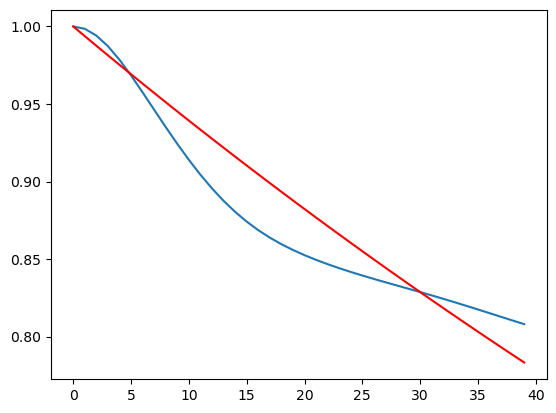

In [13]:
auto = np.zeros((40,))
for lag in range(40):
    auto[lag]=np.corrcoef(PC1[:78000-lag],PC1[lag:])[0][1]
plt.figure()
plt.plot(auto)
plt.plot([np.exp((np.log(auto[30]))*i/30) for i in range(0,40)],'r')

In [14]:
final = np.var(prec_wn1[:,27:37,:].mean(axis=1),axis=1)

final_lag_p = np.zeros((100,1))
final_lag_n = np.zeros((100,1))
for i in range(100):
    tmp            = time_idx_positive+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_p[i]   = final[tmp].mean(axis=0)
    
    tmp            = time_idx_negative+4*i
    tmp            = tmp[tmp<78000]
    final_lag_n[i]   = final[tmp].mean(axis=0)

In [15]:
# For boostrap
import random

# Generate a list of numbers from 1 to 100
nums = list(range(0, 78000))

boostrap_time = 500
random_nums = np.zeros(boostrap_time)
# Randomly choose 5 numbers from the list
for i in range(boostrap_time):
    random_nums[i] = final[random.sample(nums, 1245)].mean() 

# print("Randomly chosen numbers:", random_nums)
random_nums.mean()


0.1169072596821334

Text(0.5, 1.0, 'L = Dry z lead prec')

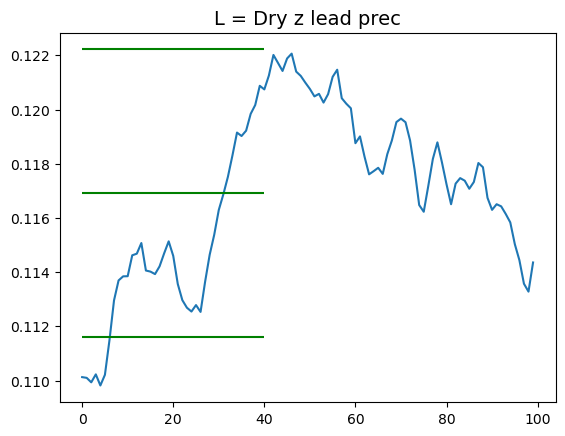

In [16]:
plt.figure()
plt.plot(final_lag_n )
plt.hlines(y = random_nums.mean(), xmin=0, xmax=40, color="Green")
plt.hlines(y = random_nums.mean() + 2* random_nums.std(), xmin=0, xmax=40, color="Green")
plt.hlines(y = random_nums.mean() - 2* random_nums.std(), xmin=0, xmax=40, color="Green")
plt.title("L = Dry z lead prec", fontsize=14)


# For prec lead m

In [18]:
y = np.linspace(-90,90,64)
dEMF_wn12_dy = np.zeros(((78000, 64, 128)))
for k in range(78000):
    for i in range(1, 64 - 1):
        dEMF_wn12_dy[k, i] = -(EMF[k, i + 1] - EMF[k, i - 1]) / (np.deg2rad(y[i + 1]) - np.deg2rad(y[i - 1]))

In [19]:
final_EMF = dEMF_wn12_dy.mean(axis=(2))[:,32:37].mean(axis=1)

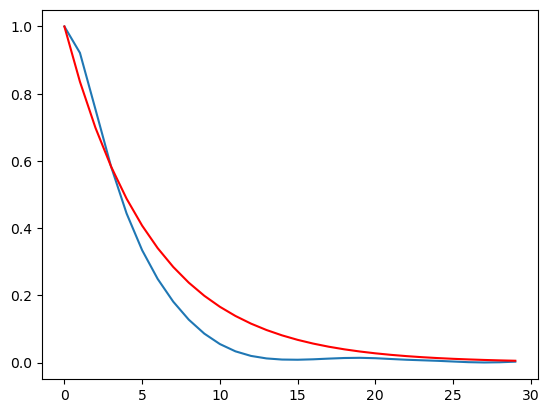

In [20]:
auto = np.zeros((30,))
for lag in range(30):
    auto[lag]=np.corrcoef(final_EMF[:78000-lag],final_EMF[lag:])[0][1]
plt.figure()
plt.plot(auto)
plt.plot([np.exp((np.log(auto[3]))*i/3) for i in range(0,30)],'r')

In [21]:
ddof_positive = PC1_positive_length*(1-auto[1])/(1+auto[1])
ddof_negative = PC1_negative_length*(1-auto[1])/(1+auto[1])
print(ddof_positive)
print(ddof_negative)


520.8133208737261
534.9489820772333


In [22]:
# For bosstrap
import random

# Generate a list of numbers from 1 to 100
nums = list(range(0, 78000))

boostrap_time = 500
random_nums = np.zeros(boostrap_time)
# Randomly choose 5 numbers from the list
for i in range(boostrap_time):
    random_nums[i] = final_EMF[random.sample(nums, int(ddof_positive))].mean()-final_EMF[random.sample(nums, int(ddof_negative))].mean()

In [23]:
tropical_precip_wn12_p = np.where((final-final.mean()) /final.std() >2*final.std())[0]
tropical_precip_wn12_n = np.where((final-final.mean()) /final.std()<-2*final.std())[0]

final_lag_EMF_p        = np.zeros((60,1))
final_lag_EMF_n        = np.zeros((60,1))

for i in range(60):
    tmp            = tropical_precip_wn12_p+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_EMF_p[i]   = final_EMF[tmp].mean(axis=0)
    
    tmp            = tropical_precip_wn12_n+4*i
    tmp            = tmp[tmp<78000] 
    final_lag_EMF_n[i]   = final_EMF[tmp].mean(axis=0)
    

Text(0.5, 1.0, 'L = Dry prec lead div m')

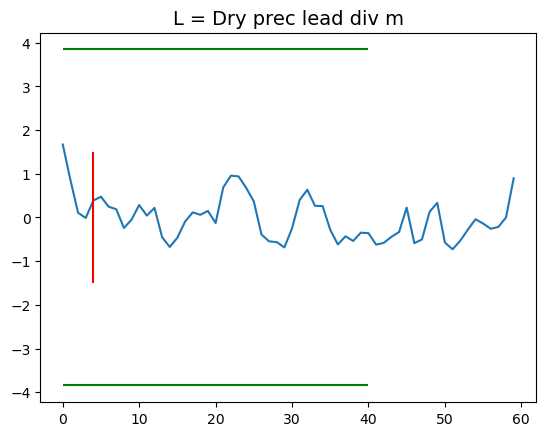

In [24]:
plt.figure()
plt.plot(final_lag_EMF_n - final_lag_EMF_p)
#plt.hist(final)
# plt.hlines(y = random_nums.mean(), xmin=0, xmax=40, color="Green")
plt.hlines(y = 2*random_nums.std(), xmin=0, xmax=40, color="Green")
plt.hlines(y = -2*random_nums.std(), xmin=0, xmax=40, color="Green")
plt.vlines(x = 4, ymin=-1.5, ymax=1.5, color="Red")
plt.title("L = Dry prec lead div m", fontsize=14)



# Try cross correlation between Z and prec

In [129]:
# colors
import matplotlib.colors as colors
import matplotlib as mpl  # Add this line

rgb=([112,115,115])
rgb=np.array(rgb)/255.0
icmap=colors.ListedColormap(rgb,name='my_color')
cmap=mpl.cm.viridis

cmap_color=icmap  
# bound=[1E-4,10E-4,25E-4,50e-4,100E-4,150E-4,200E-4,250e-4]
colors = np.array([[112,115,115],[182,203,227],[89,159,218],[0,83,170],[0,4,167],[0,140,1]])/255 # By Nick
# colors = np.array([[112,115,115],[137,209,201], [18,78,120], [242,187,5],[215,78,9],[255,16,7]])/255


In [67]:
# Function to calculate EOF and PC
def Cal_EOF_PC2(input_data):
    from EOF import EOF
    
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    eof_instance.get()

    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1 *  PC1.std(), PC1 / PC1.std()
    
def cross_corr_chunked(x, y, lag_max, chunk_size, overlap_size):
    """
    Calculate the cross-correlation between two signals x and y, using overlapping chunks.

    Parameters:
    x, y: Input signals to calculate cross-correlation.
    lag_max: Maximum number of lags to compute.
    chunk_size: Size of each chunk (default is 128).
    overlap_size: Number of points to overlap between chunks (default is 64).

    Returns:
    lags: Array of lag values.
    mean_corr: Averaged cross-correlation across all chunks.
    """
    step_size = chunk_size - overlap_size
    num_chunks = (len(x) - overlap_size) // step_size  # Number of chunks with overlap
    print(num_chunks)
    corr_matrix = np.zeros((num_chunks, 2 * lag_max + 1))  # Store cross-correlation for each chunk

    for i in range(num_chunks):
        start = i * step_size
        end = start + chunk_size

        if end > len(x) or end > len(y):  # Avoid going beyond the signal length
            break

        # Extract the chunk from x and y
        x_chunk = x[start:end]
        y_chunk = y[start:end]

        # Compute the cross-correlation for the current chunk        
        corr = np.correlate(x_chunk-np.mean(x_chunk), y_chunk-np.mean(y_chunk), mode='full')
        mid  = len(corr) // 2
        chunk_corr = corr[mid-lag_max:mid+lag_max+1] / (len(x_chunk) * np.std(x_chunk) * np.std(y_chunk))

        # Store the chunk correlation
        corr_matrix[i, :] = chunk_corr

    # Average the cross-correlation across all chunks
    mean_corr = np.mean(corr_matrix, axis=0)
    lags = np.arange(-lag_max, lag_max + 1)

    return lags, mean_corr


In [88]:
y[24:40]

array([-21.42857143, -18.57142857, -15.71428571, -12.85714286,
       -10.        ,  -7.14285714,  -4.28571429,  -1.42857143,
         1.42857143,   4.28571429,   7.14285714,  10.        ,
        12.85714286,  15.71428571,  18.57142857,  21.42857143])

270
270
270
270
270
270
270
270
270
270
270
270


FileNotFoundError: [Errno 2] No such file or directory: 'paper1_fig/fig4.png'

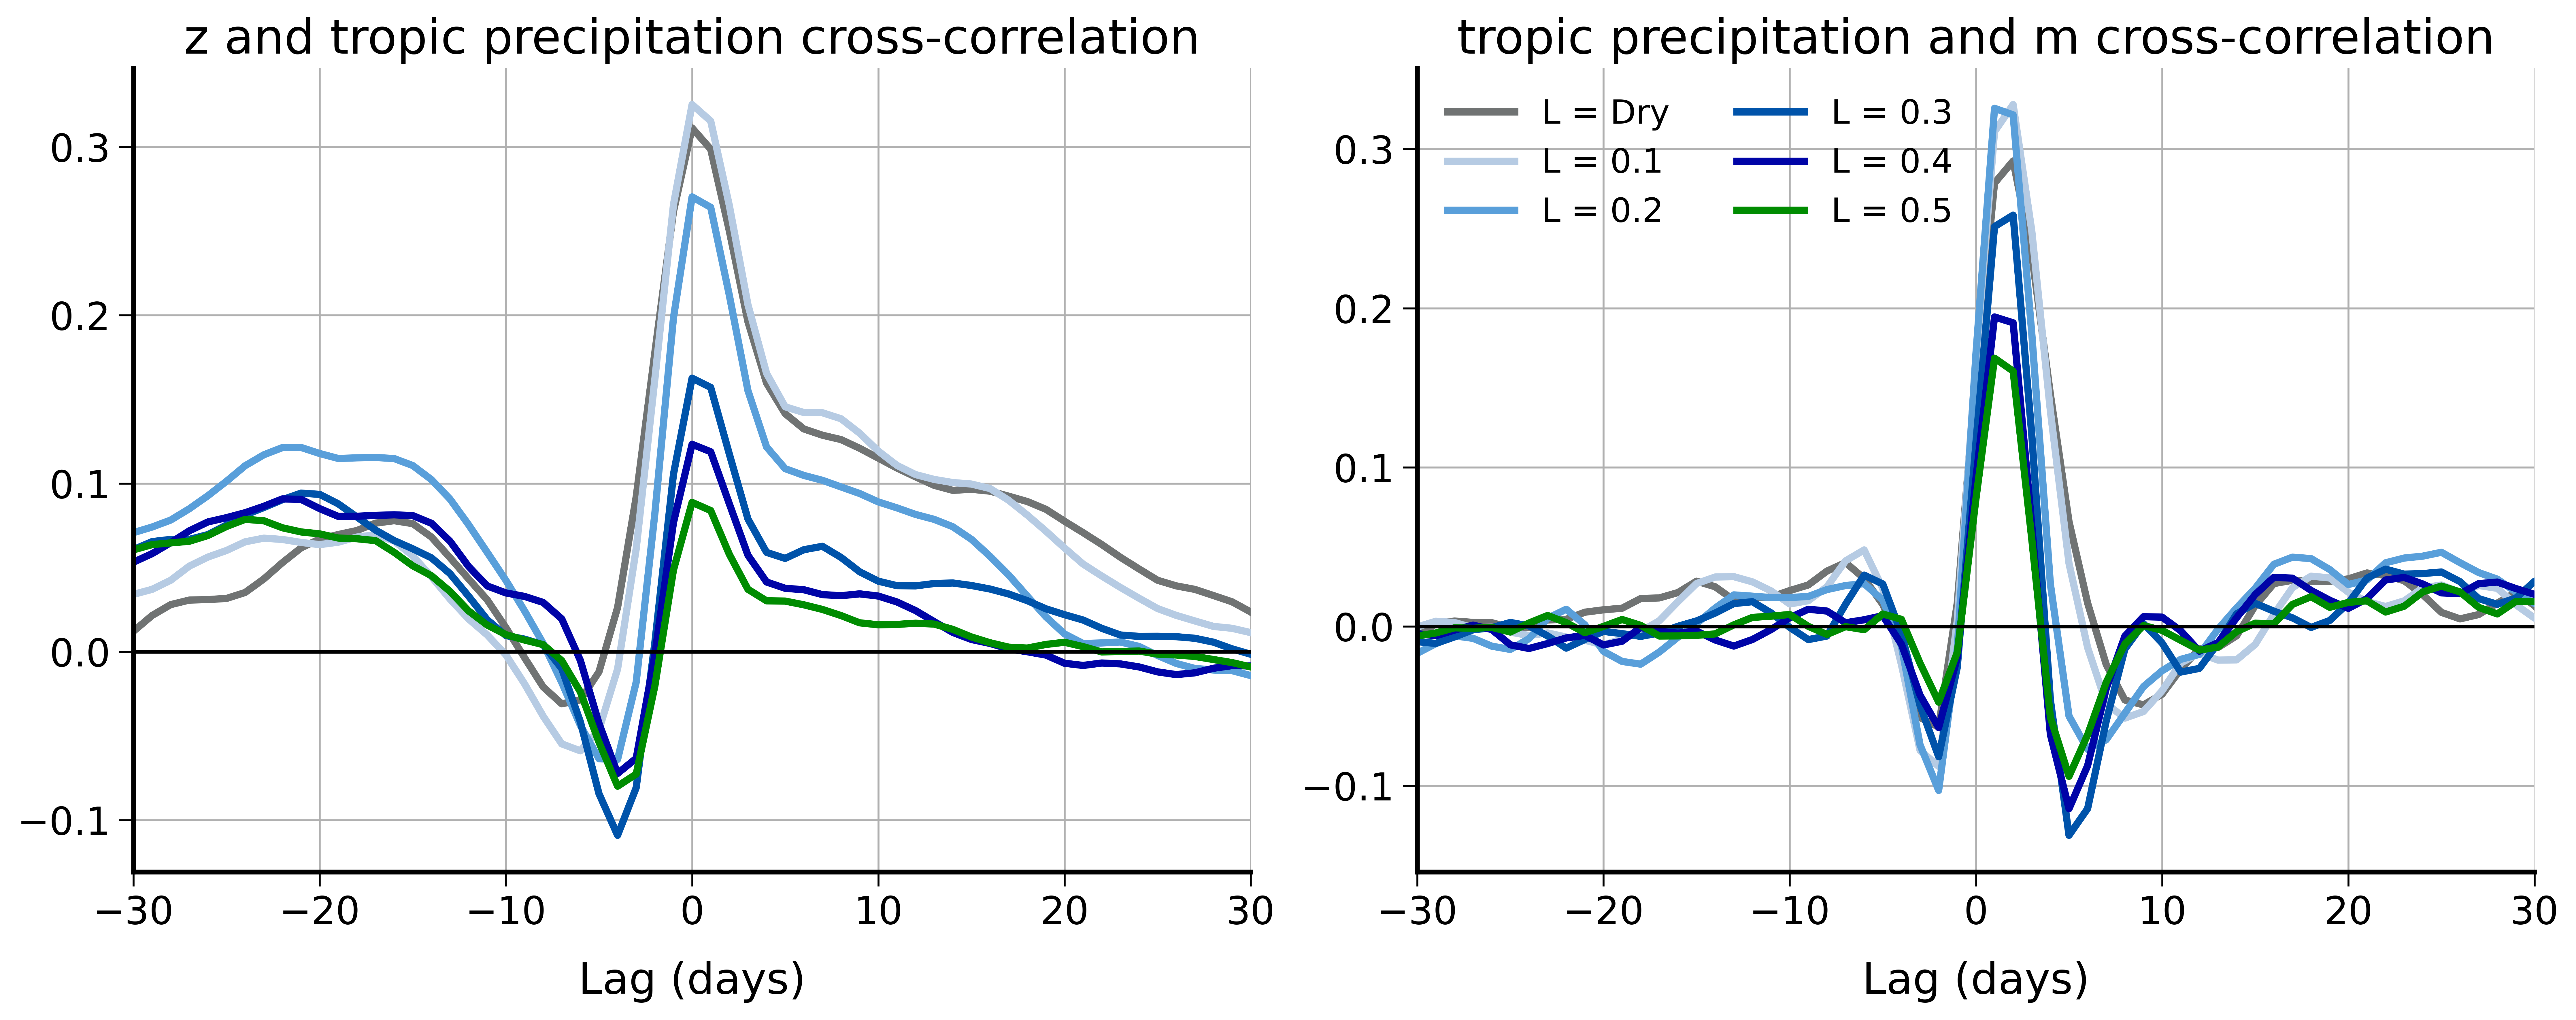

In [145]:
import matplotlib as mpl

# Main loop to compute cross-correlation of m and PC1 with chunking and overlap
fig, ax = plt.subplots(1,2, figsize=(15, 6), dpi=600.)
# Constants
radius = 6.37122e6
y = np.linspace(-90, 90, 64)
yd = np.deg2rad(y)
cy = np.cos(yd)
PR_values = range(0, 60, 10)  # PR values from 0 to 50
mpl.rcParams['axes.linewidth'] = 2

for idx, PR in enumerate(PR_values):
    # Load EMF and u data
    emf_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/Mean_6hourly_to_daily_mean/PR{PR}/EMF/PR{PR}_500_20000day_EMF_zonal_mean_daily.dat"
    with h5py.File(emf_file, "r") as u_file0:
        EMF = np.asarray(u_file0["EMF"][:,:,:]).mean(axis=1)

    u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/Mean_6hourly_to_daily_mean/PR{PR}/u/PR{PR}_500_20000day_u_zonal_mean_daily.dat"
    with h5py.File(u_file, "r") as u_file0:
        u = np.asarray(u_file0["u"][:,:,:]).mean(axis=1)
        
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
    ) as f:
        prec = f["prec"][:, 32:40]

    num_days = prec.shape[0] // 4  # Ensure divisible by 4
    prec_daily = prec[:num_days * 4].reshape(num_days, 4, *prec.shape[1:]).mean(axis=1)
    
    prec_daily *= 86400
    prec_daily_zm = prec_daily.mean(axis=2)
    prec_daily_zm_ym = np.mean(prec_daily_zm, axis=1)
    
    # Calculate EOF and PC
    EOF1, PC1           = Cal_EOF_PC2(u[:,32:])
    # EOF1_prec, PC1_prec = Cal_EOF_PC2(prec_daily_zm[:,:])

    # Prepare data for cross-correlation
    dmdy = np.zeros((19500, 64))
    Mzm = EMF
    
    for i in range(1, 64-1):
        dmdy[:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    dmdy[:,0] = -(Mzm[:,1]* (cy[1]**2) - Mzm[:,0]* (cy[1]**2)) / (radius * cy[1]**2 *(yd[1] - yd[0]))
    dmdy[:,-1] = -(Mzm[:,-1]* (cy[i]**2) - Mzm[:,-2]* (cy[i]**2)) / (radius * cy[i]**2 *(yd[-1] - yd[-2]))

    m = EOF1.dot(dmdy[:,32:].T) / (EOF1.dot(EOF1.T))
    
    m_final = (m - m.mean()) / m.std()
    PC1_final = (PC1 - PC1.mean()) / PC1.std()

    prec_daily_zm_ym_final = (prec_daily_zm_ym - prec_daily_zm_ym.mean()) / prec_daily_zm_ym.std()
    

    # Set the parameters for chunking and overlap
    auto_length = 100
    chunk_size =  128 # 128  # Set your chunk size here
    overlap_size = 56 # 64  # Set your overlap size here
    
    # Calculate cross-correlation between PC1 and m with chunking and overlap
    lags, cross_corr_values           = cross_corr_chunked(PC1_final, prec_daily_zm_ym_final, auto_length, chunk_size, overlap_size)
    lags_form, cross_corr_values_form = cross_corr_chunked(prec_daily_zm_ym_final, m_final, auto_length, chunk_size, overlap_size)
    # lags, cross_corr_values = cross_corr_chunked(m_final, PC1_final, auto_length, chunk_size, overlap_size)
    

    # Plot fig1
    if PR == 0:
        ax[0].plot(lags, cross_corr_values, label=f"L = Dry", color=colors[idx], lw=3)
    elif PR == 10:
        ax[0].plot(lags, -cross_corr_values, label=f"L = 0.1", color=colors[idx], lw=3)
    elif PR == 20:
        ax[0].plot(lags, -cross_corr_values, label=f"L = 0.2", color=colors[idx], lw=3)
    else:
        ax[0].plot(lags, cross_corr_values, label=f"L = {PR * 0.01}", color=colors[idx], lw=3)

    # Plot fig2
    if PR == 0:
        ax[1].plot(lags_form, cross_corr_values_form, label=f"L = Dry", color=colors[idx], lw=3)
    elif PR == 10:
        ax[1].plot(lags_form, -cross_corr_values_form, label=f"L = 0.1", color=colors[idx], lw=3)
    elif PR == 20:
        ax[1].plot(lags_form, -cross_corr_values_form, label=f"L = 0.2", color=colors[idx], lw=3)
    else:
        ax[1].plot(lags_form, cross_corr_values_form, label=f"L = {PR * 0.01}", color=colors[idx], lw=3)


        
    

# Finalize and show the plot
for i in range(2):
    ax[i].set_xlabel("Lag (days)", fontsize=12, labelpad=12)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].set_xlabel("Lag (days)", fontsize=18)
    ax[i].tick_params(axis='x', labelsize=16)
    ax[i].tick_params(axis='y', labelsize=16)
    ax[i].tick_params(direction='out', length=6)
    ax[i].set_xlim([-30,30])
    ax[i].grid()



# ax.set_title(f"Daily mean data: Cross-correlation of PC1 and m with chunk:{chunk_size} and overlap:{overlap_size}")
ax[0].set_title("z and tropic precipitation cross-correlation", fontsize = 20)
ax[1].set_title("tropic precipitation and m cross-correlation", fontsize = 20)
ax[0].hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")
ax[1].hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")


ax[1].legend(loc="best", prop={'size': 14},frameon=False, ncols=2)

plt.tight_layout()
plt.savefig(f"/data92/PeterChang/paper1_fig/fig4.png", bbox_inches='tight', dpi=600.)

plt.show()


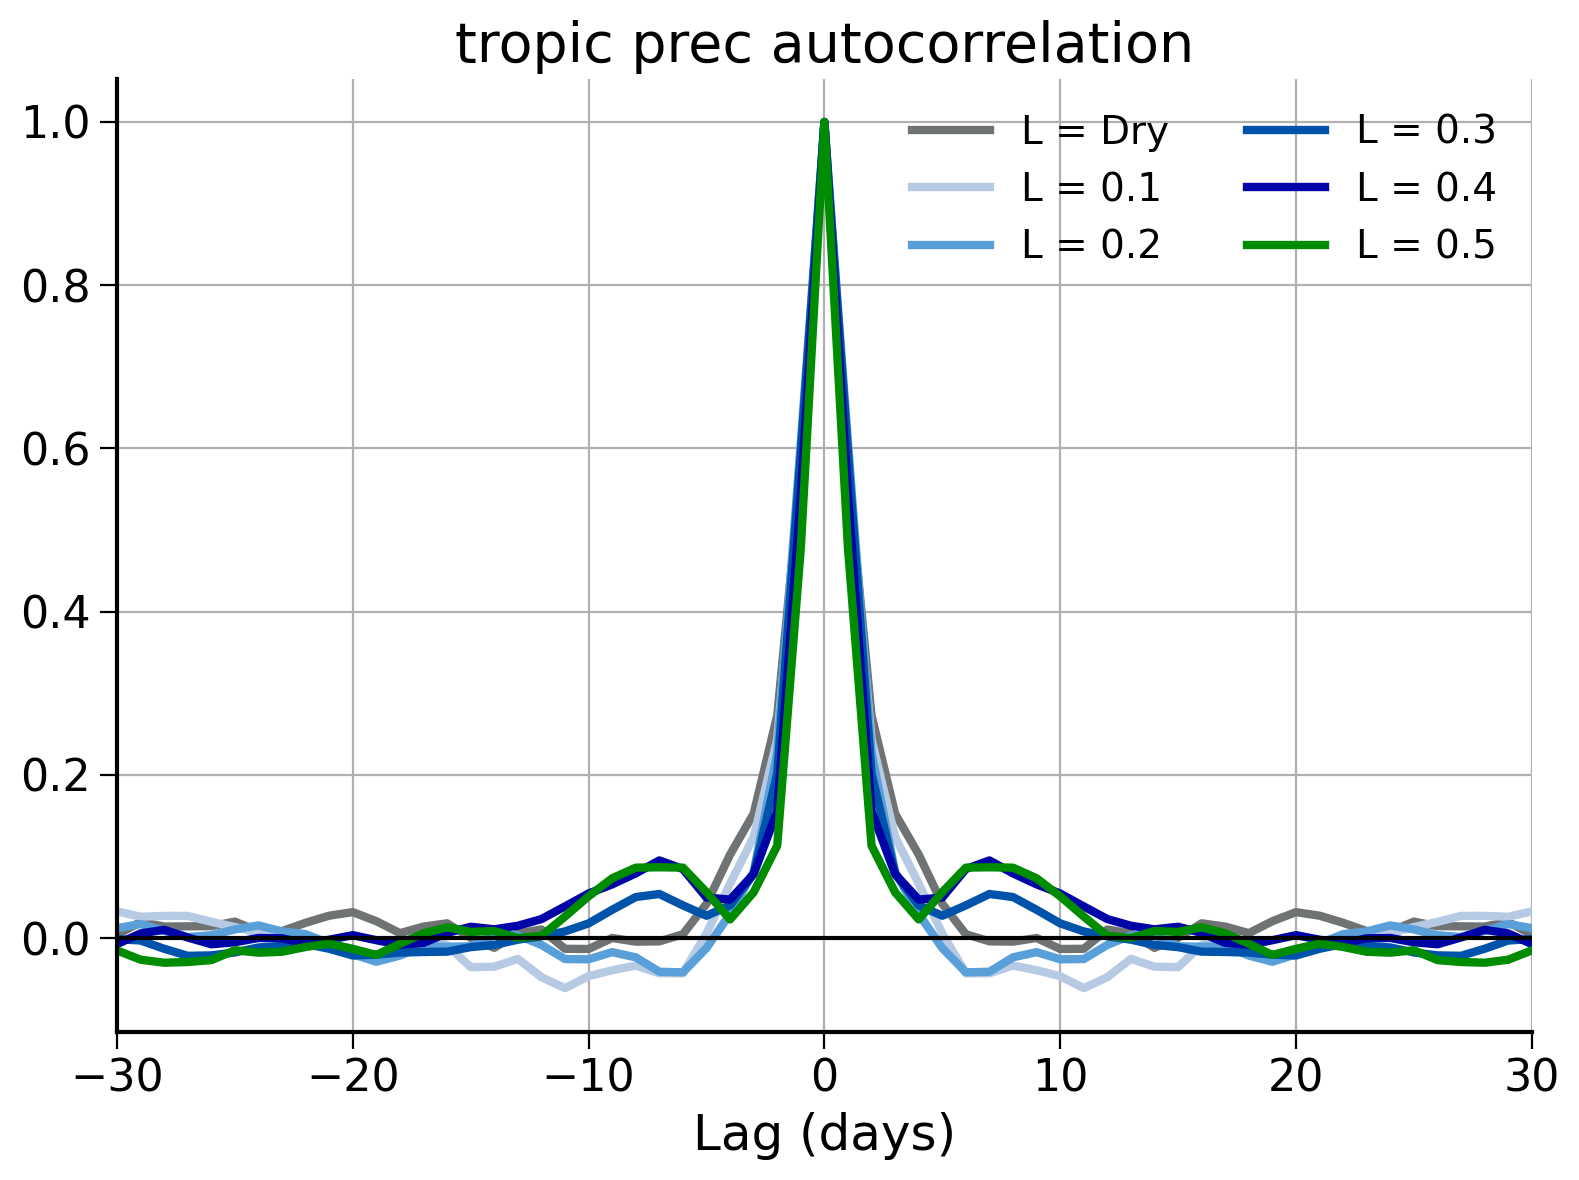

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib as mpl

# Constants
radius = 6.37122e6
y = np.linspace(-90, 90, 64)
yd = np.deg2rad(y)
cy = np.cos(yd)
PR_values = range(0, 60, 10)  # PR values from 0 to 50

# Colors for different PR values
colors = np.array([[112,115,115],[182,203,227],[89,159,218],[0,83,170],[0,4,167],[0,140,1]]) / 255

# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10]

# Function to calculate autocorrelation with chunking and overlap
def autocorr_chunked_overlap(x, lags, chunk_size, overlap_size):
    step_size = chunk_size - overlap_size
    num_chunks = (len(x) - overlap_size) // step_size
    corr = np.zeros(int(lags))

    for i in range(num_chunks):
        start = i * step_size
        end = start + chunk_size
        x_chunk = x[start:end]
        chunk_corr = np.zeros(int(lags))
        for l in range(lags):
            if l == 0:
                chunk_corr[l] = 1.
            else:
                chunk_corr[l] = np.corrcoef(x_chunk[l:], x_chunk[:-l])[0][1]
        corr += chunk_corr

    corr /= num_chunks
    return np.array(corr)

# Initialize the plot
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5
# Loop over PR values
for idx, PR in enumerate(PR_values):
    # Load prec
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
    ) as f:
        prec = f["prec"][:, 32:40]

    num_days = prec.shape[0] // 4  # Ensure divisible by 4
    prec_daily = prec[:num_days * 4].reshape(num_days, 4, *prec.shape[1:]).mean(axis=1)
    
    prec_daily *= 86400
    prec_daily_zm = prec_daily.mean(axis=2)
    prec_daily_zm_ym = np.mean(prec_daily_zm, axis=1)
    prec_daily_zm_ym_final = (prec_daily_zm_ym - prec_daily_zm_ym.mean()) / prec_daily_zm_ym.std()
    

    auto_length = 100
    chunk_size = 128  # Set your chunk size here
    overlap_size = 64  # Set your overlap size here
    yyy_thin  = autocorr_chunked_overlap(prec_daily_zm_ym_final[:], auto_length, chunk_size, overlap_size) 

    tau_full = np.arange(-auto_length+1,auto_length,1)
    yyy_thin_full = np.zeros(int(auto_length-1)*2+1) # 41
    yyy_thin_full[int((len(yyy_thin_full)+1)/2):]   = yyy_thin[1:]
    yyy_thin_full[:int((len(yyy_thin_full)+1)/2)]  = yyy_thin[::-1]

    # Plot the result for the current PR value
    if PR == 0:
        ax.plot(tau_full, yyy_thin_full, label=f"L = Dry", color=colors[idx], lw=3)
    else:
        ax.plot(tau_full, yyy_thin_full, label=f"L = {PR*0.01}", color=colors[idx], lw=3)
        

# Finalize and show the plot
# ax.set_ylabel("Autocorrelation", fontsize=14)
# ax.legend(loc="best", prop={'size': 13},frameon=False, ncols=2)
# ax.set_title(f"Daily mean data: m autocorrelation with chunk:{chunk_size} and overlap:{overlap_size}")
ax.set_title("tropic prec autocorrelation", fontsize=20)


plt.grid()
plt.hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_xlabel("Lag (days)", fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(direction='out', length=6)
ax.legend(loc="best", prop={'size': 14},frameon=False, ncols=2)

plt.xlim([-30,30])

plt.tight_layout()
# plt.savefig(f"113-1Seminar_fig/visualize/autocorrelation/m.png", bbox_inches='tight', dpi=300)
plt.show()
